In [1]:
import numpy as np
import datetime as dt
import pandas as pd
import polars as pl
from abc import ABC, abstractmethod
from typing import Dict
from dataclasses import dataclass

from __future__ import annotations


In [2]:
def load_from_cache_and_prepare(ticker: str, start_date: dt.date, end_date: dt.date,config: StratConfig):
    # load the bar data and dividends
    file_path = f'data/{ticker}.parquet'
    df = pl.scan_parquet(file_path)
    df_div = pl.read_parquet(f'data/{ticker}.div.parquet')
    # filter out to end date in paper
    df2 = df.filter((pl.col("date") >= start_date) & (pl.col("date") <= end_date)).sort('datetime').collect()
    
    df2 = df2.with_columns(pl.mean_horizontal(pl.col('high'), pl.col('low')).alias('mid'))
    # create columns with the open price of the day
    df2 = df2.with_columns((pl.int_range(pl.len()).over("date") == 0).alias("is_open"))
    df2 = df2.join(df2.filter(pl.col('is_open')).select('date', 'open').rename({'open': 'open_day'}), on='date', how='left')
    # calculate the move from the open
    df2 = df2.with_columns((pl.col('close') / pl.col('open_day') - 1).abs().alias('move'))
    # calculate the average move from the last 14 days for that time of day
    df2 = df2.with_columns(
        pl.col("move")
        .rolling_mean(window_size=config.sigma_window)  # still row-based
        .shift(1)
        .over("time")                  # or over(["time"]) for each time-of-day
        .alias("sigma")
    )
    # merge in dividends
    df2 = df2.join(df_div.rename({ticker: 'dividend'}), on='date', how='left').with_columns(pl.col('dividend').fill_null(0))
    # get the previous day's close - make sure to adjust for dividends!
    df2 = df2.with_columns(
        (pl.when(pl.col("is_open"))
            .then(pl.col("close").shift(1))
            .otherwise(None)
            .forward_fill()).alias("close_tm1")
    )
    df2 = df2.with_columns(pl.col('close_tm1') - pl.col('dividend'))

    # compute upper and lower bounds open X (1+sigma)
    df2 = df2.with_columns(
        (pl.max_horizontal(pl.col("open_day"), pl.col("close_tm1")) * (1 + pl.col("sigma"))).alias("noise_upper"),
        (pl.min_horizontal(pl.col("open_day"), pl.col("close_tm1")) * (1 - pl.col("sigma"))).alias("noise_lower")
    )

    # vwap
    df2 = df2.with_columns(df2.select('low', 'high', 'close').mean_horizontal().alias('hlc_mean'))
    df2 = df2.with_columns((pl.col('hlc_mean') * pl.col('volume')).alias('product'))
    df2 = df2.with_columns(
        (pl.col("product").cum_sum().over("date") / pl.col("volume").cum_sum().over("date")).alias("vwap")
    )
    df2 = df2.drop('hlc_mean', 'product')

    ### get daily to compute the vol scale and merge in
    df_daily = pl.read_parquet(f'data/{ticker}.daily.parquet')
    df_daily = df_daily.with_columns((pl.col(ticker) / pl.col(ticker).shift(1) - 1).alias('ret'))
    df_daily = df_daily.with_columns(pl.col("ret").shift(1).rolling_std(window_size=config.daily_vol_window).alias("vol"))
    df_daily = df_daily.with_columns(pl.min_horizontal(config.target_vol / pl.col('vol'), config.max_leverage).alias('vol_scale'))
    # df_daily.to_pandas().set_index('date')[['vol', 'vol_scale']].plot()

    df2 = df2.join(df_daily.select('date', 'vol_scale'), how='left', on='date')
    return df2, df_daily

#### Daily Data

The author isn't explicit about the price they use for signal generation (i.e. what price are we comparing to the noise boundary). I'm going to assume we are using the close price. Might be worth evaluating whether using high/low/mid has an impact on results.

this strategy does not account for financing costs of leverage

How to actually determine the trading signal? Trying to do this vectorized might be a pain, maybe better for v2

Iterative:
1. iterate day by data
2. for each day iterate in half hour intervals
3. at each half hour observation:
    1. if position is zero try to initiate by checking the signal
    2. if position is non-zero try to close by checking the signal

Vectorized:
1. determine if the close is crossing over the noise boundary
    1. if it's under lower bounds, signal is -1
    2. if it's over the upper bound signal is 1
2. for each day determine the first non-zero signal. that is the position we take.
3. 

In [3]:
class SignalStrategy(ABC):
    """
    Abstract Base Class for all trading logic.
    """
    
    @abstractmethod
    def on_rebalance(self,
                     current_pos: float,
                     data: Dict[str, float]) -> float:
        """
        Returns the new target position (1, 0, -1) based on market data.
        
        :param current_pos: The position held entering this period.
        :param data: A dictionary containing 'close', 'upper', 'lower', etc.
        """
        pass


class MomentumOppBand(SignalStrategy):
    def on_rebalance(self, current_pos, data):
        close = data['close_lag']
        upper = data['noise_upper_lag']
        lower = data['noise_lower_lag']
        
        # 1. Exit Logic
        if current_pos == 1 and close < lower:
            return 0.0
        elif current_pos == -1 and close > upper:
            return 0.0
            
        # 2. Entry Logic (only if flat)
        if current_pos == 0:
            if close > upper:
                return 1.0
            elif close < lower:
                return -1.0
        
        # 3. Hold Logic (default)
        return current_pos

class MomentumVWAP(SignalStrategy):
    do_vol_scaling = False
    def on_rebalance(self, current_pos, data):
        close = data['close_lag']
        upper = data['noise_upper_lag']
        lower = data['noise_lower_lag']
        vwap = data['vwap_lag']
        vol_scale = 1
        if self.do_vol_scaling:
            vol_scale = data['vol_scale_lag']

        # 1. Exit Logic
        if current_pos > 0 and close < max(upper, vwap):
            return 0.0
        elif current_pos < 0 and close > min(lower, vwap):
            return 0.0

        # 2. Entry Logic (only if flat)
        if current_pos == 0:
            if close > max(upper, vwap):
                return 1.0 * vol_scale
            elif close < min(lower, vwap):
                return -1.0 * vol_scale

        # 3. Hold Logic (default)
        return current_pos

class MomentumVWAPVolScale(MomentumVWAP):
    do_vol_scaling = True

class SimpleTrendStrategy(SignalStrategy):
    def on_rebalance(self, current_pos, data):
        # Example: Buy if close > open, Sell if close < open
        if data['close_lag'] > data['open_day_lag']:
            return 1.0
        return -1.0

In [4]:
def run_backtest(xf: pl.DataFrame, strategy: SignalStrategy, config: StratConfig):
    # -----------------------------------------------------------
    # 1. PRE-PROCESSING (Same as before, but generic columns)
    # -----------------------------------------------------------
    xf = xf.sort("datetime")

    # Shift columns required by strategies
    # (You might want to shift ALL float columns to be safe)
    cols_to_shift = ["close", "noise_upper", "noise_lower", "open_day", "vwap", "vol_scale"]
    xf_signals = xf.with_columns([
        pl.col(c).shift(config.obs_lag).alias(f"{c}_lag") for c in cols_to_shift
    ])

    # Generate Schedule & Align
    times = pl.time_range(dt.time(9, 30), dt.time(16, 0), "30m", eager=True)
    schedule_df = (
        xf_signals.select("date").unique().sort("date")
        .join(pl.DataFrame({"time_target": times}), how="cross")
        .with_columns(target_dt = pl.col("date").dt.combine(pl.col("time_target")))
    )
    schedule_df = schedule_df.with_columns(pl.col("target_dt").dt.replace_time_zone('US/Eastern').dt.cast_time_unit('us'))

    rebal_df = schedule_df.join_asof(
        xf_signals, left_on="target_dt", right_on="datetime", strategy="backward"
    ).sort("target_dt")
    # -----------------------------------------------------------
    # 2. STATE MACHINE (Using the Strategy Object)
    # -----------------------------------------------------------
    # Convert to dictionary of numpy arrays for fast access
    # This allows the strategy to access any column by name
    data_arrays = {
        col: rebal_df[col].to_numpy()
        for col in rebal_df.columns if col not in ["target_dt", "date"]
    }

    times = rebal_df["time_target"].to_list()
    dates = rebal_df["date"].to_list()
    n = len(rebal_df)

    signals = np.zeros(n)
    positions = np.zeros(n)  # Representing share count
    aum_vector = np.zeros(n)
    cash_vector = np.zeros(n)
    current_signal = 0.0
    current_cash = config.starting_aum  # Initial Cash
    prev_aum_eod = config.starting_aum  # Yesterday's Close AUM (for sizing)
    current_pos_shares = 0

    for i in range(n):
        is_new_day = (i == 0) or (dates[i] != dates[i-1])
        is_eod = (i == n - 1) or (dates[i+1] != dates[i]) or (times[i] >= dt.time(16, 0))

        row_data = {k: v[i] for k, v in data_arrays.items()}

        # 1. Update AUM_TM1 (Anchor for sizing)
        if is_new_day:
            prev_aum_eod = aum_vector[i-1] if i > 0 else config.starting_aum
        else:
            current_signal = strategy.on_rebalance(current_signal, row_data)

        # Force Exit EOD
        if is_eod:
            current_signal = 0.0

        # 3. Calculate Target Shares
        if row_data['close'] > 0:
            target_shares = (prev_aum_eod * current_signal) / row_data['open_day']
        else:
            target_shares = 0.0

        shares_traded = target_shares - current_pos_shares

        # Cash Flow = (Shares Sold * Price) - (Shares Bought * Price) - Comm
        # Note: shares_traded > 0 means buying (cash outflow), < 0 means selling (cash inflow)
        execution_price = row_data[config.execution_price]
        trade_cost = shares_traded * execution_price
        comm_cost = abs(shares_traded) * config.commission
        
        # Update State
        current_cash = current_cash - trade_cost - comm_cost
        current_pos_shares = target_shares
        
        # Update AUM (Mark to Market)
        current_exposure = current_pos_shares * execution_price
        current_aum = current_cash + current_exposure

        signals[i] = current_signal
        positions[i] = current_pos_shares
        cash_vector[i] = current_cash
        aum_vector[i] = current_aum

    # -----------------------------------------------------------
    # 3. MERGE RESULTS
    # -----------------------------------------------------------
    rebal_df = rebal_df.with_columns(pl.Series("signal_new", signals)).with_columns(pl.Series("aum", aum_vector)).with_columns(pl.Series("cash", cash_vector)).with_columns(pl.Series("shares", positions))

    final_xf = xf.join(
        rebal_df.select(["datetime", "signal_new", "aum", "cash", "shares"]),
        on="datetime",
        how='left',
    ).with_columns(pl.col("signal_new").forward_fill().alias("signal")
    ).with_columns(pl.col("shares").forward_fill()
    ).with_columns(pl.col("cash").forward_fill()
    ).with_columns(
        pl.when(pl.col("aum").is_not_null())
        .then(pl.col("aum"))
        .otherwise(pl.col("cash") + pl.col("shares") * pl.col("close"))
    )

    return final_xf, rebal_df


In [5]:
def calc_stats(res):
    import statsmodels.api as sm

    # 1. Convert AUM to Daily Returns
    # This assumes 'res' columns are strategy names and index is dates
    returns_df = res.pct_change().dropna()

    # 2. Define the Benchmark (X variable)
    benchmark_col = 'bnh'
    if benchmark_col not in returns_df.columns:
        raise ValueError(f"Benchmark column '{benchmark_col}' not found in the DataFrame.")

    X_bench = sm.add_constant(returns_df[benchmark_col])

    # 3. Initialize a list to store results
    all_stats = []

    # 4. Loop through every strategy in the frame
    for strategy_name in res.columns:
        # Select specific strategy data
        strat_ret = returns_df[strategy_name]
        strat_aum = res[strategy_name]
        
        # Calculate performance metrics
        total_ret = (strat_aum.iloc[-1] / strat_aum.iloc[0]) - 1
        ann_ret = (1 + total_ret) ** (252 / len(strat_ret)) - 1
        ann_vol = strat_ret.std() * np.sqrt(252)
        sharpe = (strat_ret.mean() / strat_ret.std()) * np.sqrt(252) if strat_ret.std() != 0 else 0
        
        # Hit Ratio: Days with positive return / Days with any movement
        active_days = strat_ret.abs() > 0
        hit_ratio = (strat_ret[active_days] > 0).sum() / active_days.sum() if active_days.sum() > 0 else 0
        
        # Max Drawdown
        rolling_max = strat_aum.cummax()
        drawdown = (strat_aum - rolling_max) / rolling_max
        max_dd = drawdown.min()

        # 5. Regression against "bnh"
        Y = strat_ret
        model = sm.OLS(Y, X_bench).fit()
        alpha = model.params.const * 252  # Annualized Alpha
        beta = model.params[benchmark_col]

        # Store in dictionary
        all_stats.append({
            'Strategy': strategy_name,
            'Total Return (%)': round(total_ret * 100, 1),
            'Ann. Return (%)': round(ann_ret * 100, 1),
            'Ann. Volatility (%)': round(ann_vol * 100, 1),
            'Sharpe Ratio': round(sharpe, 2),
            'Hit Ratio (%)': round(hit_ratio * 100, 1),
            'Max Drawdown (%)': round(max_dd * -100, 1),
            'Alpha vs BNH (%)': round(alpha * 100, 2),
            'Beta vs BNH': round(beta, 2)
        })

    # 6. Display as a clean DataFrame
    stats_summary = pd.DataFrame(all_stats).set_index('Strategy')
    return stats_summary.T

In [6]:
@dataclass
class StratConfig:
    sigma_window: int = 14
    daily_vol_window: int = 14
    target_vol: float = 0.02
    max_leverage: int = 4
    starting_aum: int = 100000
    commission: float = 0.0035
    min_comm_per_order: float = 0.35
    obs_lag: int = 1
    execution_price: str = 'close'

ticker = 'IVV.US'
start_date = dt.date(2007, 1, 1)
end_date = dt.date(2025, 4, 30)

config = StratConfig()

df2, df_daily = load_from_cache_and_prepare(ticker, start_date, end_date, config)

<Axes: title={'center': 'IVV.US'}, xlabel='date'>

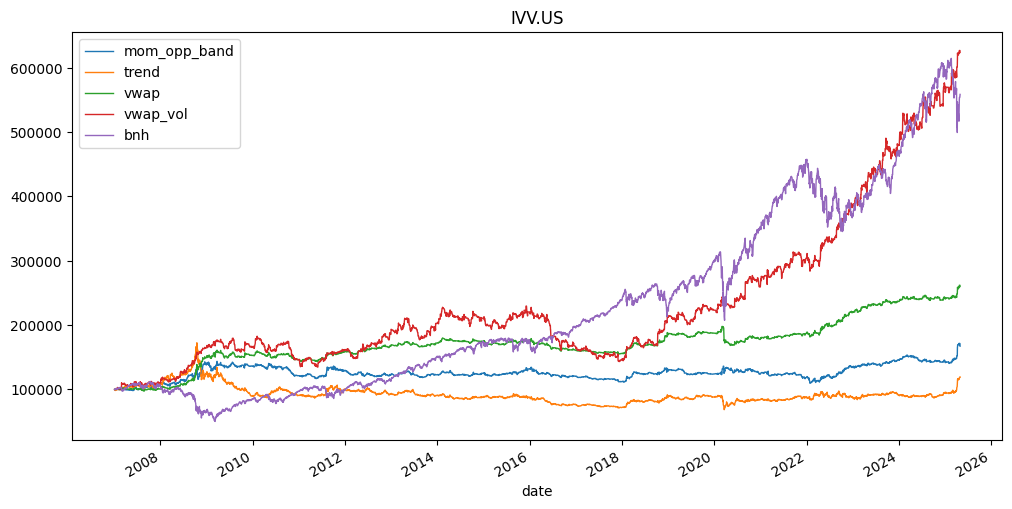

In [7]:
# when we are actually computing the trade signal, we should be using lagged data.
# meaning, if we are evaluating at 10:30 AM we should only be looking at data through 10:30 - obs_lag

xf_mom_vwap_vol, rebal_mom_vwap_vol = run_backtest(df2, MomentumVWAPVolScale(), config=config)
xf_mom, rebal_mom = run_backtest(df2, MomentumOppBand(), config=config)
xf_trend, rebal_trend = run_backtest(df2, SimpleTrendStrategy(), config=config)
xf_mom_vwap, rebal_mom_vwap = run_backtest(df2, MomentumVWAP(), config=config)

res = xf_mom.group_by('date').agg(pl.col('aum').last()).sort('date').to_pandas().set_index('date').rename(columns={'aum': 'mom_opp_band'})
res_tmp = xf_trend.group_by('date').agg(pl.col('aum').last()).sort('date').to_pandas().set_index('date').rename(columns={'aum': 'trend'})
res_vwap = xf_mom_vwap.group_by('date').agg(pl.col('aum').last()).sort('date').to_pandas().set_index('date').rename(columns={'aum': 'vwap'})
res_vwap_vol = xf_mom_vwap_vol.group_by('date').agg(pl.col('aum').last()).sort('date').to_pandas().set_index('date').rename(columns={'aum': 'vwap_vol'})
res_bnh = df_daily.to_pandas().set_index('date')[ticker].rename('bnh').pct_change().fillna(0).add(1).cumprod().mul(config.starting_aum)

res = res.join(res_tmp).join(res_vwap).join(res_vwap_vol).join(res_bnh)
res.plot(linewidth=1, figsize=(12, 6), title=ticker)

In [ ]:
calc_stats(res)

Strategy,mom_opp_band,trend,vwap,vwap_vol,bnh
Total Return (%),67.20,19.70,160.00,523.90,458.70
Ann. Return (%),2.80,1.00,5.40,10.50,9.90
Ann. Volatility (%),10.30,13.90,7.50,14.50,19.80
Sharpe Ratio,0.32,0.14,0.73,0.76,0.57
Hit Ratio (%),52.30,50.70,42.00,42.00,54.70
Max Drawdown (%),23.70,60.30,15.00,37.60,55.30
Alpha vs BNH (%),3.84,2.07,6.03,11.94,0.00
Beta vs BNH,-0.04,-0.01,-0.05,-0.08,1.00


### Debugging

In [9]:
res_vwap_vol.to_parquet('debug/mine.parquet')

In [10]:
xf_pd = xf_mom_vwap_vol.filter(pl.col('date') == dt.date(2018, 2, 6)).to_pandas().set_index('time')
xf_pd['trade'] = xf_pd['signal'] != xf_pd['signal'].shift(-1)
xf_pd[xf_pd['trade']][['close', 'shares', 'noise_upper', 'noise_lower', 'vwap', 'vol_scale', 'signal_new', 'signal', 'open_day', 'close_tm1', 'sigma', 'aum', 'cash']]

,close,shares,noise_upper,noise_lower,vwap,vol_scale,signal_new,signal,open_day,close_tm1,sigma,aum,cash
time,,,,,,,,,,,,,
09:59:00,267.7695,0.000000,266.273837,261.492088,264.806642,1.431623,NaN,0.000000,261.88,265.88,0.001481,162604.721476,162604.721476
10:29:00,265.2800,888.913237,266.380339,261.387188,265.731231,1.431623,NaN,1.431623,261.88,265.88,0.001882,159676.463491,-76134.439982
12:29:00,267.3190,0.000000,266.512508,261.257008,265.517104,1.431623,NaN,0.000000,261.88,265.88,0.002379,159593.350103,159593.350103
13:29:00,266.6300,888.913237,266.811613,260.962402,265.727474,1.431623,NaN,1.431623,261.88,265.88,0.003504,158663.724640,-78347.211702
14:59:00,268.7400,0.000000,267.233457,260.546904,265.737082,1.431623,NaN,0.000000,261.88,265.88,0.005090,158303.003649,158303.003649
15:59:00,271.1400,888.913237,267.702127,260.085286,266.557674,1.431623,NaN,1.431623,261.88,265.88,0.006853,160406.616824,-80613.318217
16:00:00,271.0400,0.000000,267.685649,260.101516,266.570929,1.431623,0.0,0.000000,261.88,265.88,0.006791,160314.614304,160314.614304


In [11]:
"""
The PnL in the paper is calculated incorrectly?
    it looks like the close prices are :29/:59?
"""

((265.28/267.76)*(266.63/267.319)*(271.04/268.74)-1)*2.386

-0.008012816880546392

In [12]:
xf_pd = xf_mom_vwap_vol.filter(pl.col('date') == dt.date(2018, 2, 6)).to_pandas().set_index('time')
xf_pd['trade'] = xf_pd['signal'] != xf_pd['signal'].shift(1)
xf_pd[xf_pd['trade']][['close', 'shares', 'noise_upper', 'noise_lower', 'vwap', 'vol_scale', 'signal_new', 'signal', 'open_day', 'close_tm1', 'sigma', 'aum', 'cash']]

,close,shares,noise_upper,noise_lower,vwap,vol_scale,signal_new,signal,open_day,close_tm1,sigma,aum,cash
time,,,,,,,,,,,,,
09:30:00,260.6300,0.000000,266.002988,261.758862,261.033333,1.431623,0.000000,0.000000,261.88,265.88,0.000463,162604.721476,162604.721476
10:00:00,268.5707,888.913237,266.267702,261.498131,264.875966,1.431623,1.431623,1.431623,261.88,265.88,0.001458,162601.610279,-76134.439982
10:30:00,265.1900,0.000000,266.351086,261.416001,265.729060,1.431623,0.000000,0.000000,261.88,265.88,0.001772,159593.350103,159593.350103
12:30:00,267.6723,888.913237,266.509957,261.259520,265.529922,1.431623,1.431623,1.431623,261.88,265.88,0.002369,159590.238907,-78347.211702
13:30:00,266.2277,0.000000,266.791205,260.982504,265.727977,1.431623,0.000000,0.000000,261.88,265.88,0.003427,158303.003649,158303.003649
15:00:00,268.7700,888.913237,267.264360,260.516467,265.743044,1.431623,1.431623,1.431623,261.88,265.88,0.005207,158299.892452,-80613.318217
16:00:00,271.0400,0.000000,267.685649,260.101516,266.570929,1.431623,0.000000,0.000000,261.88,265.88,0.006791,160314.614304,160314.614304


In [13]:
"""
This is using :30/:00 close prices
"""
((265.19/268.57)*(266.22/267.67)*(271.04/268.77)-1)*2.29

-0.02207491849361879

<Axes: xlabel='time'>

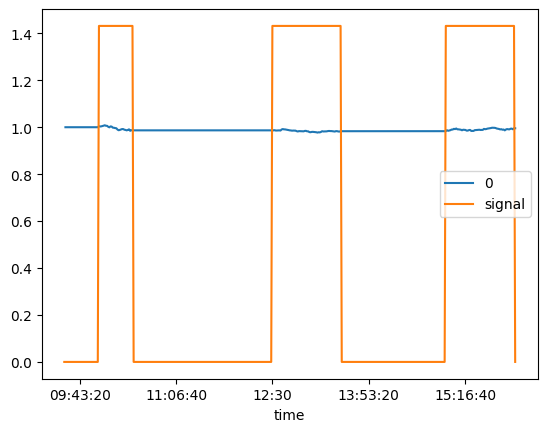

In [14]:
(xf_pd['signal'] * xf_pd['close'].pct_change()).add(1).cumprod().to_frame().join(xf_pd['signal']).plot()